<a href="https://colab.research.google.com/github/Omar-Ahmed-Kandel/Housing-Pricing-Project/blob/main/Housing_Pricing_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = fetch_california_housing(as_frame=True).frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


array([[<Axes: title={'center': 'MedHouseVal'}>]], dtype=object)

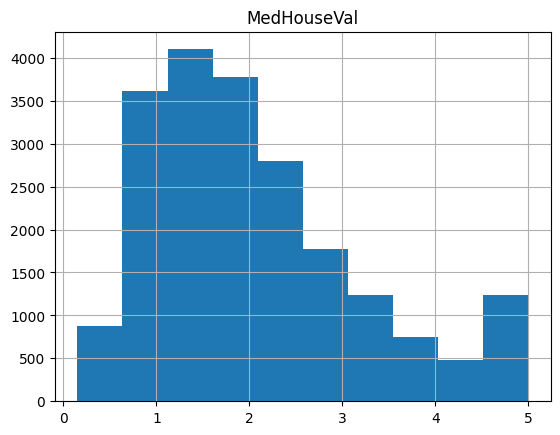

In [ ]:
df.hist("MedHouseVal") # label

In [ ]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

array([[<Axes: title={'center': 'MedInc'}>]], dtype=object)

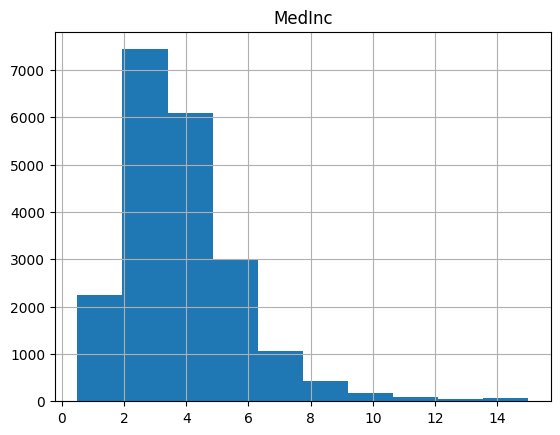

In [ ]:
sdf = df[['MedInc']]
sdf.hist()

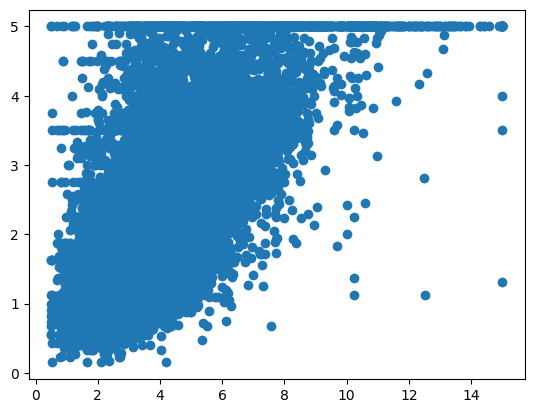

In [ ]:
plt.scatter(data=df, x='MedInc', y='MedHouseVal')

In [ ]:
corr_df = df[['MedInc','MedHouseVal']]
corr_df.corr()

,MedInc,MedHouseVal
MedInc,1.000000,0.688075
MedHouseVal,0.688075,1.000000


In [ ]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (16512, 8)
y_train shape: (16512,)


In [ ]:
min_train = X_train.min()
max_train = X_train.max()

X_train_norm = (X_train - min_train) / (max_train - min_train)
X_test_norm = (X_test - min_train) / (max_train - min_train)
print(X_train_norm.max())
print(X_train_norm.min())

MedInc        1.0
HouseAge      1.0
AveRooms      1.0
AveBedrms     1.0
Population    1.0
AveOccup      1.0
Latitude      1.0
Longitude     1.0
dtype: float64
MedInc        0.0
HouseAge      0.0
AveRooms      0.0
AveBedrms     0.0
Population    0.0
AveOccup      0.0
Latitude      0.0
Longitude     0.0
dtype: float64


In [ ]:
model = LinearRegression()
model.fit(X_train_norm, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test_norm)

In [ ]:
multi_model = LinearRegression()
multi_model.fit(X_train_norm,y_train)
print(f"Coff: {multi_model.coef_} \n Intercept: {multi_model.intercept_}")

Coff: [  6.50587593   0.49593713 -17.39108272  19.81593931  -0.07241483
  -4.38194802  -3.94604937  -4.35442897] 
 Intercept: 3.6270717454244346


In [ ]:
print("Model Results")
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Model Results
R²: 0.5757877060324511
MAE: 0.533200130495656
RMSE: 0.7455813830127761


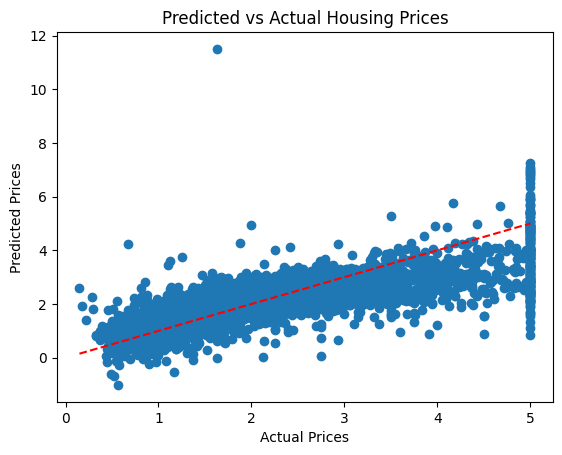

In [ ]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Predicted vs Actual Housing Prices")
plt.show()